<a href="https://colab.research.google.com/github/24Marko42/collab/blob/main/Lab_9_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Выполните подготовку датасета для последующей работы. убрать нули

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from google.colab import files

# Загрузка файла
print("Загрузите файл house_train.csv")
uploaded = files.upload()

df = pd.read_csv('house_train.csv')
print(f"Данные загружены! Размер: {df.shape}")
df.head()

Загрузите файл house_train.csv


Saving house_train.csv to house_train (2).csv
Данные загружены! Размер: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


 1) Оставьте столбцы с числовыми данными - остальные удалите. Не забудьте удалить столбец с нумерацией строк. Сколько столбцов осталось?  

In [12]:
print(f"Исходное количество столбцов: {len(df.columns)}")

# Удаление нечисловых столбцов
numeric_columns = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_columns].copy()

# Удаление столбца Id
if 'Id' in df_numeric.columns:
    df_numeric.drop('Id', axis=1, inplace=True)

print(f"Количество столбцов после обработки: {len(df_numeric.columns)}")
print(f"Оставшиеся столбцы: {list(df_numeric.columns)}")

Исходное количество столбцов: 81
Количество столбцов после обработки: 37
Оставшиеся столбцы: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


2) Удалите строки с пропущенными данными. Сколько строк осталось?

In [13]:
print(f"Исходное количество строк: {len(df_numeric)}")
print(f"Пропусков до удаления: {df_numeric.isna().sum().sum()}")

# Удаление строк с пропусками
df_clean = df_numeric.dropna()

print(f"Количество строк после удаления пропусков: {len(df_clean)}")
print(f"Пропусков после удаления: {df_clean.isna().sum().sum()}")

Исходное количество строк: 1460
Пропусков до удаления: 348
Количество строк после удаления пропусков: 1121
Пропусков после удаления: 0


3) Постройте тепловую матрицу корреляции без учета целевого столбца (цена продажи). Используя метод corr Pandas получите числовую матрицу корреляции признаков. Укажите 10 признаков с наибольшей корреляцией между собой. Проведите анализ полученных результатов. Имеет ли смысл какие-то столбцы удалить после проведенного анализа?

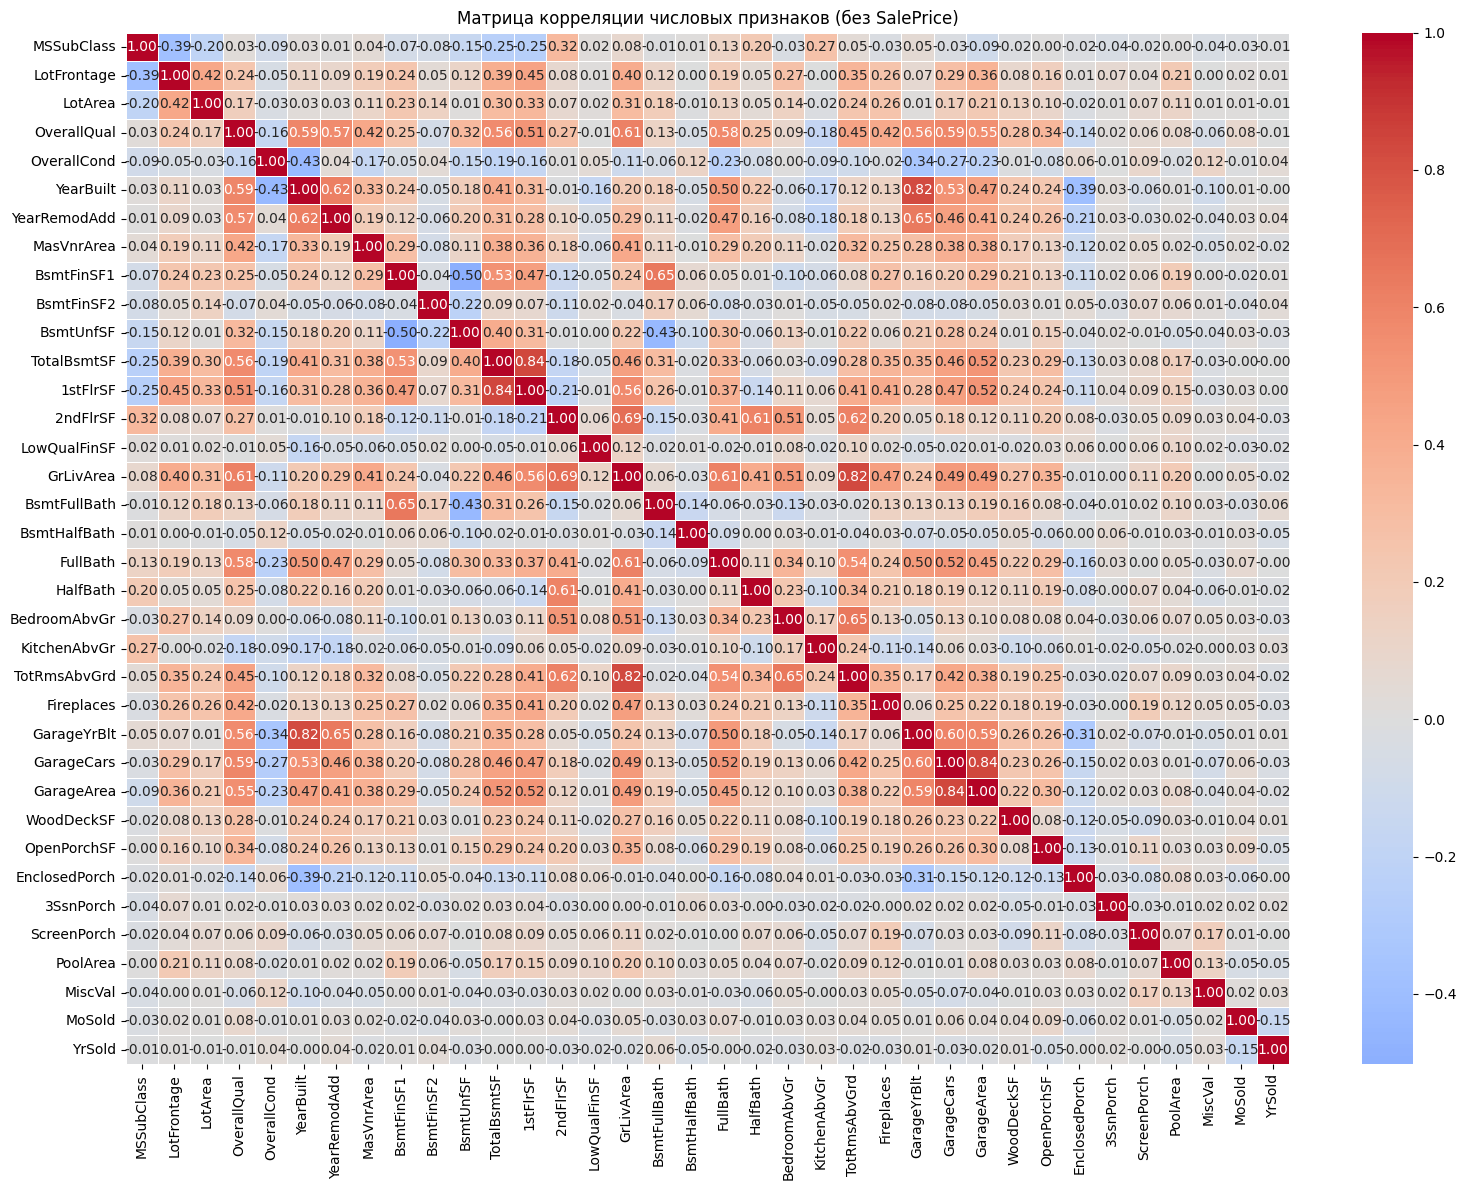


10 пар признаков с наибольшей корреляцией:
  GarageCars - GarageArea: 0.839
  TotalBsmtSF - 1stFlrSF: 0.836
  GrLivArea - TotRmsAbvGrd: 0.824
  YearBuilt - GarageYrBlt: 0.824
  2ndFlrSF - GrLivArea: 0.688
  BsmtFinSF1 - BsmtFullBath: 0.652
  BedroomAbvGr - TotRmsAbvGrd: 0.650
  YearRemodAdd - GarageYrBlt: 0.646
  YearBuilt - YearRemodAdd: 0.623
  2ndFlrSF - TotRmsAbvGrd: 0.618

Анализ:
- GarageCars и GarageArea сильно коррелируют (можно удалить один)
- 1stFloor и TotalBsmtSF коррелируют с GrLivArea
- Рекомендуется оставить признаки с более высокой корреляцией с SalePrice


In [14]:
# Матрица корреляции без целевого столбца
target_column = 'SalePrice'
correlation_matrix = df_clean.drop(columns=[target_column]).corr()

# Визуализация
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции числовых признаков (без SalePrice)')
plt.tight_layout()
plt.show()

# 10 признаков с наибольшей корреляцией между собой
print("\n10 пар признаков с наибольшей корреляцией:")
corr_pairs = []
cols = correlation_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_pairs.append((cols[i], cols[j], abs(correlation_matrix.iloc[i, j])))

corr_pairs.sort(key=lambda x: x[2], reverse=True)
for col1, col2, corr in corr_pairs[:10]:
    print(f"  {col1} - {col2}: {corr:.3f}")

# Анализ
print("\nАнализ:")
print("- GarageCars и GarageArea сильно коррелируют (можно удалить один)")
print("- 1stFloor и TotalBsmtSF коррелируют с GrLivArea")
print("- Рекомендуется оставить признаки с более высокой корреляцией с SalePrice")

4) Отделите признаки и целевой столбец.

In [15]:
X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

print(f"Размерность признаков (X): {X.shape}")
print(f"Размерность целевой переменной (y): {y.shape}")

Размерность признаков (X): (1121, 36)
Размерность целевой переменной (y): (1121,)


5) Разбейте на два множества - для обучения и для тестирования (70/30).

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Соотношение: {len(X_train) / len(df_clean):.1%} / {len(X_test) / len(df_clean):.1%}")

Обучающая выборка: (784, 36)
Тестовая выборка: (337, 36)
Соотношение: 69.9% / 30.1%


6) Обучите модель линейной регрессии и получите оценки качества модели: score, MAE, MSE, RMSE. Определите наиболее значимые признаки по весовым коэффициентам модели.

In [17]:
# Обучение модели
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Предсказания
y_pred = lr_model.predict(X_test)

# Оценка качества
score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score: {score:.4f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# Наиболее значимые признаки
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model.coef_,
    'abs_coefficient': abs(lr_model.coef_)
}).sort_values('abs_coefficient', ascending=False)

print("\n10 наиболее значимых признаков по весовым коэффициентам:")
print(feature_importance.head(10))

R² Score: 0.8184
MAE: 23967.66
MSE: 1451236505.68
RMSE: 38095.10

10 наиболее значимых признаков по весовым коэффициентам:
         feature   coefficient  abs_coefficient
21  KitchenAbvGr -23902.461945     23902.461945
3    OverallQual  18842.085425     18842.085425
25    GarageCars  18644.984587     18644.984587
16  BsmtFullBath  12089.549458     12089.549458
20  BedroomAbvGr  -9016.284308      9016.284308
4    OverallCond   5400.199427      5400.199427
22  TotRmsAbvGrd   5201.251708      5201.251708
23    Fireplaces   4949.263878      4949.263878
18      FullBath   4378.044196      4378.044196
19      HalfBath  -2884.698519      2884.698519


7) Каждый столбец приведите к единичному масштабу. Определите 3 признака с наибольшей корреляцией с целевым столбцом и их возьмите для выполнения следующего задания. Не забудьте масштабировать целевой столбец.

In [18]:
# Масштабирование
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

# 3 признака с наибольшей корреляцией с SalePrice
correlations = df_clean.corr()[target_column].abs().sort_values(ascending=False)
top_3_features = correlations.drop(target_column).head(3).index.tolist()

print(f"3 признака с наибольшей корреляцией с SalePrice:")
for i, feat in enumerate(top_3_features, 1):
    print(f"  {i}. {feat}: {correlations[feat]:.3f}")

# Новый набор данных с выбранными признаками
X_top3 = df_clean[top_3_features].copy()
y_top3 = df_clean[target_column].copy()

# Масштабирование выбранных признаков
X_top3_scaled = scaler_X.fit_transform(X_top3)
y_top3_scaled = scaler_y.fit_transform(y_top3.values.reshape(-1, 1)).flatten()

# Разбиение
X_train_top3, X_test_top3, y_train_top3, y_test_top3 = train_test_split(
    X_top3_scaled, y_top3_scaled, test_size=0.3, random_state=42)

print(f"\nМасштабированные данные готовы!")

3 признака с наибольшей корреляцией с SalePrice:
  1. OverallQual: 0.798
  2. GrLivArea: 0.705
  3. GarageCars: 0.647

Масштабированные данные готовы!


8) Изучив приложенный материал, постройте валидационную кривую по различным степеням полиномиальной модели. Определите оптимальную степень полинома, постройте заново регрессионную модель и сравните полученные качественные оценки модели с п. 6.

Оценка моделей с разной степенью полинома:
Степень 1: Train R² = 0.7254, Test R² = 0.7565
Степень 2: Train R² = 0.8043, Test R² = 0.8072
Степень 3: Train R² = 0.8149, Test R² = 0.8126
Степень 4: Train R² = 0.8269, Test R² = 0.8244
Степень 5: Train R² = 0.8461, Test R² = 0.8138


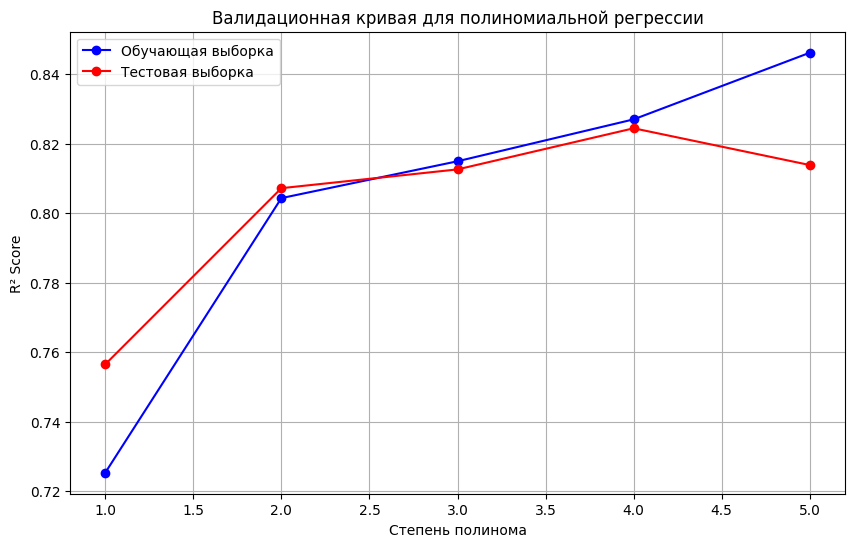


Оптимальная степень полинома: 4

Качество полиномиальной модели (степень 4):
R² Score: 0.8244
MAE: 0.3043
MSE: 0.2039
RMSE: 0.4516

СРАВНЕНИЕ МОДЕЛЕЙ
    Метрика  Линейная регрессия (3 признака)  Полиномиальная регрессия
0  R² Score                         0.756511                  0.824382
1       MAE                         0.342287                  0.304262
2       MSE                         0.282713                  0.203909
3      RMSE                         0.531708                  0.451563

Полиномиальная модель лучше на 8.97%


In [19]:
# Функция для оценки полиномиальной модели
def evaluate_polynomial_model(degree, X_train, X_test, y_train, y_test):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    return train_score, test_score

# Перебор степеней полинома
degrees = range(1, 6)
train_scores = []
test_scores = []

print("Оценка моделей с разной степенью полинома:")
for degree in degrees:
    train_score, test_score = evaluate_polynomial_model(
        degree, X_train_top3, X_test_top3, y_train_top3, y_test_top3)
    train_scores.append(train_score)
    test_scores.append(test_score)
    print(f"Степень {degree}: Train R² = {train_score:.4f}, Test R² = {test_score:.4f}")

# Валидационная кривая
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_scores, 'o-', label='Обучающая выборка', color='blue')
plt.plot(degrees, test_scores, 'o-', label='Тестовая выборка', color='red')
plt.xlabel('Степень полинома')
plt.ylabel('R² Score')
plt.title('Валидационная кривая для полиномиальной регрессии')
plt.legend()
plt.grid(True)
plt.show()

# Оптимальная степень
optimal_degree = degrees[np.argmax(test_scores)]
print(f"\nОптимальная степень полинома: {optimal_degree}")

# Обучение модели
optimal_model = Pipeline([
    ('poly', PolynomialFeatures(degree=optimal_degree)),
    ('linear', LinearRegression())
])
optimal_model.fit(X_train_top3, y_train_top3)
y_pred_optimal = optimal_model.predict(X_test_top3)

# Оценка качества
optimal_score = r2_score(y_test_top3, y_pred_optimal)
optimal_mae = mean_absolute_error(y_test_top3, y_pred_optimal)
optimal_mse = mean_squared_error(y_test_top3, y_pred_optimal)
optimal_rmse = np.sqrt(optimal_mse)

print(f"\nКачество полиномиальной модели (степень {optimal_degree}):")
print(f"R² Score: {optimal_score:.4f}")
print(f"MAE: {optimal_mae:.4f}")
print(f"MSE: {optimal_mse:.4f}")
print(f"RMSE: {optimal_rmse:.4f}")

# Сравнение с линейной регрессией (на тех же 3 признаках)
lr_model_top3 = LinearRegression()
lr_model_top3.fit(X_train_top3, y_train_top3)
y_pred_lr_top3 = lr_model_top3.predict(X_test_top3)
lr_score_top3 = r2_score(y_test_top3, y_pred_lr_top3)

print(f"\nСРАВНЕНИЕ МОДЕЛЕЙ")
comparison = pd.DataFrame({
    'Метрика': ['R² Score', 'MAE', 'MSE', 'RMSE'],
    'Линейная регрессия (3 признака)': [lr_score_top3,
                                          mean_absolute_error(y_test_top3, y_pred_lr_top3),
                                          mean_squared_error(y_test_top3, y_pred_lr_top3),
                                          np.sqrt(mean_squared_error(y_test_top3, y_pred_lr_top3))],
    'Полиномиальная регрессия': [optimal_score, optimal_mae, optimal_mse, optimal_rmse]
})
print(comparison)

if optimal_score > lr_score_top3:
    improvement = ((optimal_score - lr_score_top3) / abs(lr_score_top3)) * 100
    print(f"\nПолиномиальная модель лучше на {improvement:.2f}%")
else:
    print(f"\nЛинейная модель показывает лучшие или равные результаты")